# 6.6.2 Sampling time — Figures 6–8 and Supplementary Figures S4–S6
This notebook shows setup, sampling, and how to reproduce each sweep. The supplementary IOX/Matérn comparison uses a full dense covariance factorization; the structured IOX implementation is also available via `iox_dense=False`.

Recorded plotting tables are embedded below to reproduce original hardware timings. The live small benchmark measures this run. Main panel (b) is setup plus mean sampling time; supplementary panel (b) is setup only.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "scripts/models").is_dir())
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from threadpoolctl import threadpool_limits
from scripts.common import core
MODEL_DIR = ROOT / "results/analysis/model_fit"
FIGURES = ROOT / "results/figures"
FIGURES.mkdir(parents=True, exist_ok=True)
payload = core.load_pickle_cross_platform(MODEL_DIR / "models.pkl")

In [2]:
from scripts.analysis.computation.sampling_benchmark import run_sampling, plot_summary
live = run_sampling(payload, stations=(40,), periods=(9,), realizations=(100,),
                    methods=("Kronecker", "PCA", "LMC", "IOX full semivariogram"), iox_dense=True)
display(live)

Kronecker: n=40, m=9, draws=100, total=0.001641 s


PCA: n=40, m=9, draws=100, total=0.001975 s


LMC: n=40, m=9, draws=100, total=0.001959 s


IOX full semivariogram: n=40, m=9, draws=100, total=0.006458 s


,method,n_stations,n_periods,n_realizations,repeat,setup_seconds,sampling_seconds_total,sampling_seconds_per_realization,total_seconds,first_realization_seconds
0,Kronecker,40,9,100,0,0.001144,0.000497,0.000005,0.001641,0.001149
1,PCA,40,9,100,0,0.001471,0.000504,0.000005,0.001975,0.001476
2,LMC,40,9,100,0,0.000823,0.001136,0.000011,0.001959,0.000835
3,IOX full semivariogram,40,9,100,0,0.005850,0.000608,0.000006,0.006458,0.005856


## Full sweeps
Set `RERUN=True` to time the full main sweep. Station counts reach 5120: a dense 9-period covariance then needs about 17 GB before factorization/work arrays. Restrict dense models or use a suitable memory limit. No missing point is filled with an extrapolated time.

In [3]:
RERUN = False
if RERUN:
    methods = ("Kronecker", "PCA", "LMC", "LMC conventional method")
    station_run = run_sampling(payload, stations=(20,40,80,160,320,640,1280,2560,5120), methods=methods, max_dense_gb=8.)
    period_run = run_sampling(payload, stations=(640,), periods=(1,2,3,4,5,6,7,8,9), methods=methods)
    draw_run = run_sampling(payload, stations=(640,), realizations=(1,10,100,1000,10000), methods=methods)
    station_plot = plot_summary(station_run, "station")
    display(station_plot)

# The supplementary comparison uses six models and dense IOX.
RERUN_SUPPLEMENT = False
if RERUN_SUPPLEMENT:
    extra_methods = ("Kronecker", "PCA", "LMC", "IOX full semivariogram", "SBSS semivariogram", "Multivariate Matern semivariogram")
    supplement_station_run = run_sampling(payload, stations=(20,40,80,160,320,640,1280,2560,5120), methods=extra_methods, max_dense_gb=8., iox_dense=True)
    supplement_period_run = run_sampling(payload, stations=(640,), periods=tuple(range(1,10)), methods=extra_methods, iox_dense=True)
    supplement_realization_run = run_sampling(payload, stations=(640,), realizations=(1,10,100,1000,10000), methods=extra_methods, iox_dense=True)


## Recorded main station sweep

In [4]:
import io
main_station = pd.read_csv(io.StringIO('method,station_count,median_total_seconds,median_setup_seconds,median_first_realization_seconds,median_sampling_seconds_per_realization\r\nIOX full semivariogram,20,0.003400900051929,0.0030303000239655,0.0030340060242451,3.706000279635191e-06\r\nLMC semivariogram,20,0.0015173000283539,0.0009164999937638,0.0009225079941097,6.008000345900655e-06\r\nMultivariate Matern semivariogram,20,0.0029538000235334,0.0026451000012457,0.0026481870014686,3.087000222876668e-06\r\nPCA semivariogram,20,0.0015564999775961,0.0012127999798394,0.001216236979817,3.4369999775663018e-06\r\nSBSS semivariogram,20,0.0017642999882809,0.0014658999862149,0.0014688839862355,2.98400002066046e-06\r\nSeparable kernel semivariogram,20,0.0031649000011384,0.0029115999350324,0.0029141329356934,2.533000661060214e-06\r\nIOX full semivariogram,40,0.0085198000306263,0.0077846000203862,0.0077919520204886,7.352000102400779e-06\r\nLMC semivariogram,40,0.002292999997735,0.0010055999737232,0.0010184739739634,1.2874000240117312e-05\r\nMultivariate Matern semivariogram,40,0.0119785999995656,0.0112111999769695,0.0112188739771954,7.674000225961209e-06\r\nPCA semivariogram,40,0.0021523999748751,0.0015037999837659,0.001510285983677,6.485999911092222e-06\r\nSBSS semivariogram,40,0.0026836000033654,0.0020266000065021,0.0020331700064707,6.569999968633056e-06\r\nSeparable kernel semivariogram,40,0.0021569000091403,0.0014674999983981,0.0014743939985055,6.894000107422471e-06\r\nIOX full semivariogram,80,0.0346766000729985,0.032256500038784,0.0322807010391261,2.4201000342145563e-05\r\nLMC semivariogram,80,0.0076947000343352,0.0013244000729173,0.0013881030725315,6.370299961417913e-05\r\nMultivariate Matern semivariogram,80,0.0453189000254496,0.0434303000220097,0.0434491860220441,1.888600003439933e-05\r\nPCA semivariogram,80,0.0044342000037431,0.0024447999894618,0.0024646939896047,1.989400014281273e-05\r\nSBSS semivariogram,80,0.0041826000087894,0.0026390000130049,0.0026544360129628,1.5435999957844616e-05\r\nSeparable kernel semivariogram,80,0.0070754000917077,0.0010924000525847,0.0011522300529759,5.983000039122999e-05\r\nIOX full semivariogram,160,0.1412167999660596,0.1350830000010319,0.1351443380006821,6.13379996502772e-05\r\nLMC semivariogram,160,0.0183012000052258,0.0035140999825671,0.0036619709827937,0.0001478710002265\r\nMultivariate Matern semivariogram,160,0.1365678999572992,0.1319126999587752,0.1319592519587604,4.65519999852404e-05\r\nPCA semivariogram,160,0.0122052999795414,0.0084225999889895,0.008460426988895,3.782699990551919e-05\r\nSBSS semivariogram,160,0.0125643999199382,0.0085103999590501,0.008550939958659,4.053999960888177e-05\r\nSeparable kernel semivariogram,160,0.0119388999883085,0.0022088999394327,0.0023061999399214,9.730000048875808e-05\r\nIOX full semivariogram,320,0.745487799984403,0.7242281000362709,0.7244406970357522,0.0002125969994813\r\nLMC semivariogram,320,0.0206252000061795,0.0089172999141737,0.0090343789150938,0.00011707900092\r\nMultivariate Matern semivariogram,320,0.7314171000034548,0.7172927999636158,0.7174340429640143,0.0001412430003983\r\nPCA semivariogram,320,0.0437205999623984,0.0359968999982811,0.0360741369979223,7.723699964117259e-05\r\nSBSS semivariogram,320,0.0357513999915681,0.0285282999975606,0.0286005309975007,7.223099994007497e-05\r\nSeparable kernel semivariogram,320,0.010160700068809,0.0058605000376701,0.0059035020379815,4.3002000311389565e-05\r\nIOX full semivariogram,640,3.5639198999269865,3.524076299974695,3.5244747359742177,0.0003984359995229\r\nLMC semivariogram,640,0.1320343998959288,0.0775517999427393,0.0780966259422712,0.0005448259995318\r\nMultivariate Matern semivariogram,640,3.76733050000621,3.7069497000193214,3.707553508019191,0.0006038079998688\r\nPCA semivariogram,640,0.2456172000383958,0.2249711000476963,0.2251775610476033,0.0002064609999069\r\nSBSS semivariogram,640,0.2409216999658383,0.2279388000024482,0.2280686290020821,0.0001298289996339\r\nSeparable kernel semivariogram,640,0.040504700038582,0.0319282000418752,0.0320139650418423,8.576499996706843e-05\r\nIOX full semivariogram,1280,,0.0479392000124789,,\r\nLMC semivariogram,1280,0.4686691999668255,0.376663799979724,0.377583853979595,0.000920053999871\r\nMultivariate Matern semivariogram,1280,,0.072194300009869,,\r\nPCA semivariogram,1280,1.1200362000381574,1.069372000056319,1.0698786420561373,0.0005066419998183\r\nSBSS semivariogram,1280,1.1654944999609145,1.1367393999826163,1.1370269509823994,0.0002875509997829\r\nSeparable kernel semivariogram,1280,0.1758544001495465,0.1569501000922173,0.1571391430927906,0.0001890430005732\r\nIOX full semivariogram,2560,,0.2054546999861486,,\r\nLMC semivariogram,2560,1.993351300014183,1.7722820000490174,1.774492693048669,0.0022106929996516\r\nMultivariate Matern semivariogram,2560,,0.1844648999976925,,\r\nPCA semivariogram,2560,5.681117699947208,5.551262299995869,5.552560853995383,0.0012985539995133\r\nSBSS semivariogram,2560,5.127509999962058,5.059469599975273,5.060150003975141,0.0006804039998678\r\nSeparable kernel semivariogram,2560,0.7797128999372944,0.7244124999269843,0.7249655039270874,0.0005530040001031\r\nIOX full semivariogram,5120,,0.9241418999736196,,\r\nLMC semivariogram,5120,8.347289900062606,7.83928630000446,7.8443663360050415,0.0050800360005814\r\nMultivariate Matern semivariogram,5120,,0.7678370000212453,,\r\nPCA semivariogram,5120,28.199070999922697,27.667511299951,27.67282689695072,0.0053155969997169\r\nSBSS semivariogram,5120,20.32797850004863,20.152029999997467,20.15378948499798,0.0017594850005116\r\nSeparable kernel semivariogram,5120,3.292329799965956,3.1668738999869674,3.1681284589867573,0.0012545589997898\r\nLMC conventional method,20,0.0032284001354128,0.0013059000484645,0.001325125049334,1.922500086948276e-05\r\nLMC conventional method,40,0.0030184998176991,0.0021888997871428,0.0021971957874484,8.296000305563212e-06\r\nLMC conventional method,80,0.0131952001247555,0.0114424000494182,0.0114599280501715,1.7528000753372908e-05\r\nLMC conventional method,160,0.046327999792993,0.0432599999476224,0.0432906799460761,3.06799984537065e-05\r\nLMC conventional method,320,0.3457915000617504,0.3334820999298244,0.3336051939311437,0.0001230940013192\r\nLMC conventional method,640,1.9082770003005864,1.8860886001493784,1.8863104841508904,0.000221884001512\r\nLMC conventional method,1280,9.462405199883506,9.395082499831917,9.39575572683243,0.0006732270005159\r\nLMC conventional method,2560,58.20119259995408,57.93654659995809,57.93919305995805,0.0026464599999599\r\nLMC conventional method,5120,,,,\r\n'))
display(main_station)

,method,station_count,median_total_seconds,median_setup_seconds,median_first_realization_seconds,median_sampling_seconds_per_realization
0,IOX full semivariogram,20,0.003401,0.003030,0.003034,0.000004
1,LMC semivariogram,20,0.001517,0.000916,0.000923,0.000006
2,Multivariate Matern semivariogram,20,0.002954,0.002645,0.002648,0.000003
3,PCA semivariogram,20,0.001556,0.001213,0.001216,0.000003
4,SBSS semivariogram,20,0.001764,0.001466,0.001469,0.000003
...,...,...,...,...,...,...
58,LMC conventional method,320,0.345792,0.333482,0.333605,0.000123
59,LMC conventional method,640,1.908277,1.886089,1.886310,0.000222
60,LMC conventional method,1280,9.462405,9.395082,9.395756,0.000673
61,LMC conventional method,2560,58.201193,57.936547,57.939193,0.002646


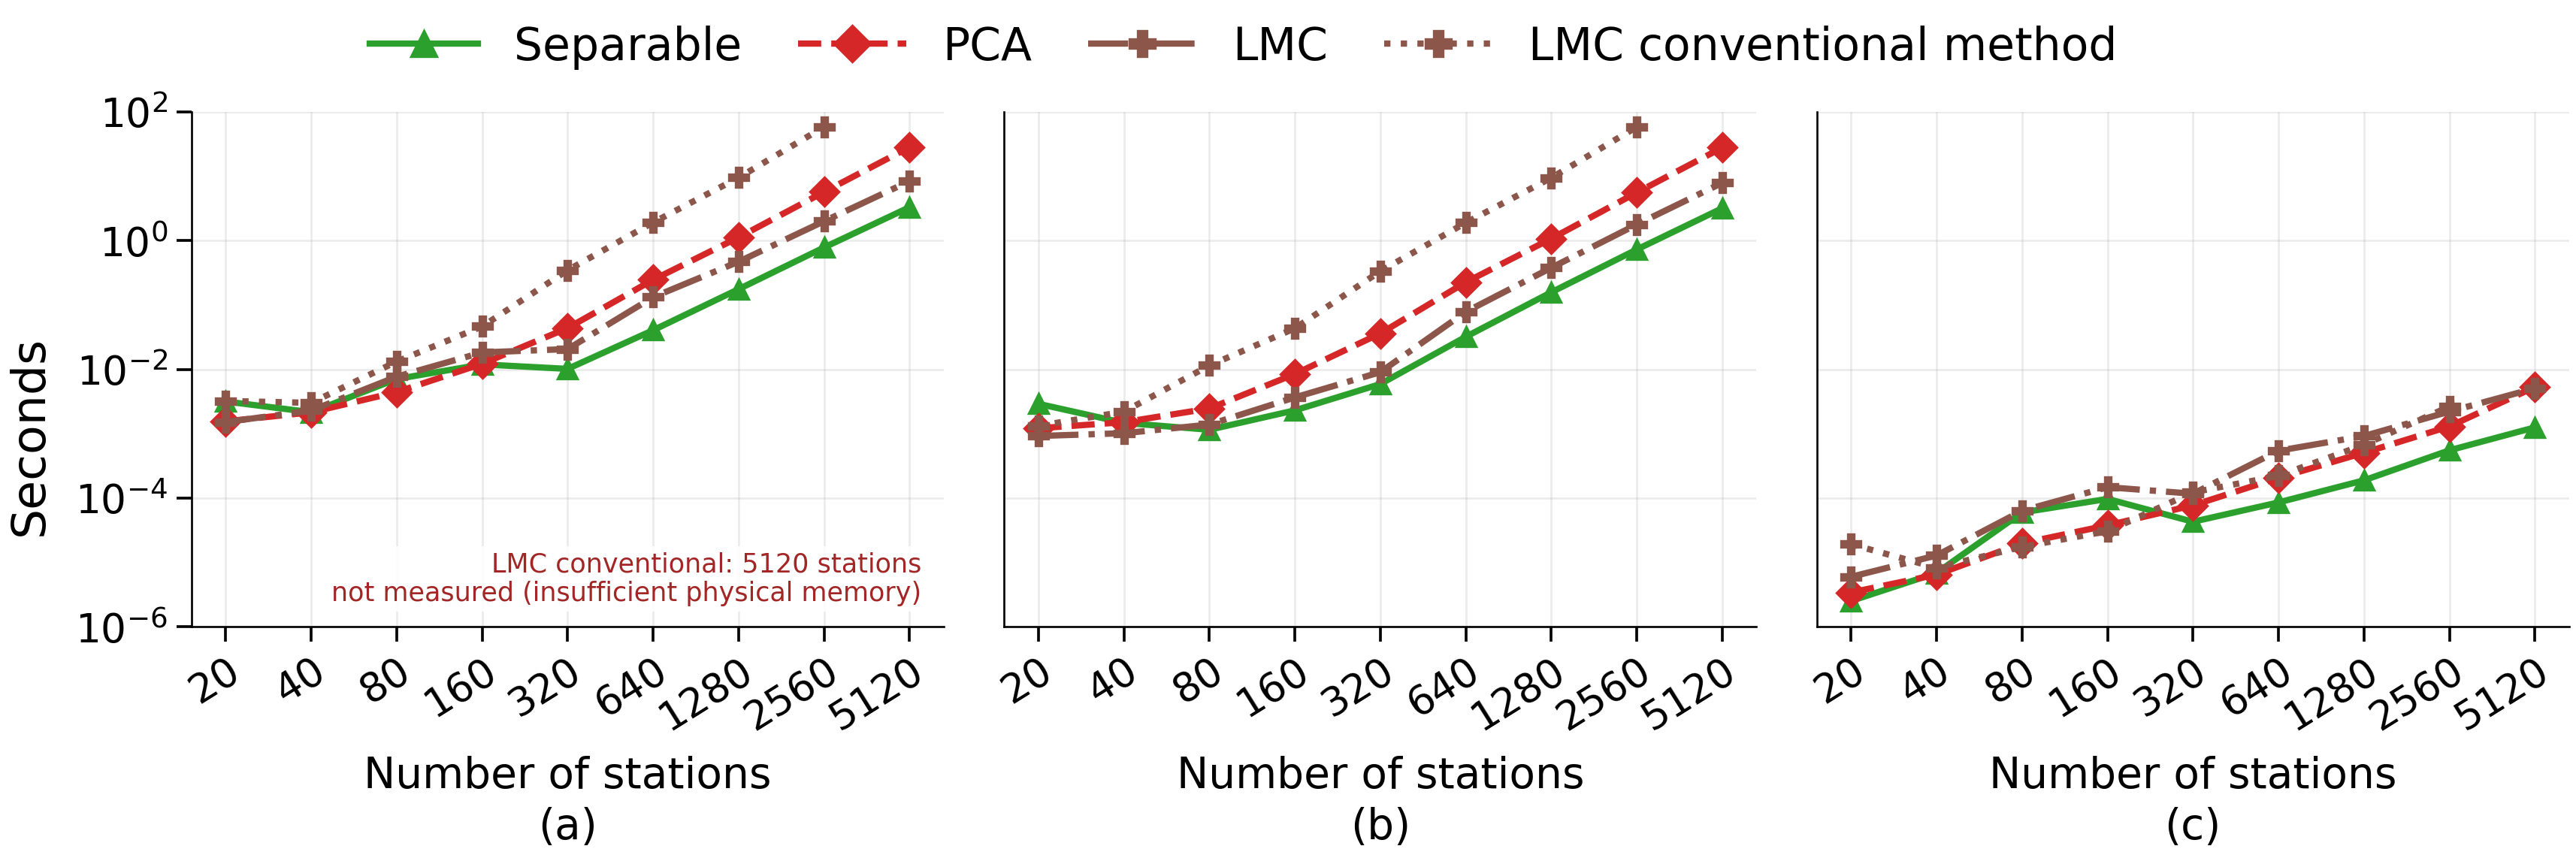

In [5]:
if RERUN:
    main_station = plot_summary(station_run, 'station')
from scripts.common import plotting as p
p.plot_sweep(main_station, x_column='station_count', x_label="Number of stations", output_path=FIGURES / 'fig06_sampling_stations.png', log_x_base=2)
display(Image(filename=str(FIGURES / 'fig06_sampling_stations.png')))

## Recorded main period sweep

In [6]:
import io
main_period = pd.read_csv(io.StringIO('method,period_count,median_total_seconds,median_setup_seconds,median_first_realization_seconds,median_sampling_seconds_per_realization\r\nIOX full semivariogram,1,0.0393802999751642,0.038344100001268,0.038354462001007,1.0361999738961458e-05\r\nLMC semivariogram,1,0.0840094999875873,0.0789281000616028,0.0789789140608627,5.081399925984442e-05\r\nMultivariate Matern semivariogram,1,0.039088100020308,0.0375454999739304,0.0375609259743941,1.542600046377629e-05\r\nPCA semivariogram,1,0.225872499984689,0.214936000003945,0.2150453650037525,0.0001093649998074\r\nSBSS semivariogram,1,0.268491199996788,0.2593143000267446,0.259406069026445,9.17689997004345e-05\r\nSeparable kernel semivariogram,1,0.0424730000086128,0.0400674000848084,0.0400914560840465,2.4055999238044023e-05\r\nIOX full semivariogram,2,0.1279961999971419,0.1253782999701798,0.1254044789704494,2.617900026962161e-05\r\nLMC semivariogram,2,0.0901066999649629,0.0788394999690353,0.0789521719689946,0.0001126719999592\r\nMultivariate Matern semivariogram,2,0.1301220000023022,0.1276192999794148,0.1276443269796436,2.5027000228874387e-05\r\nPCA semivariogram,2,0.232779300014954,0.2222282000002451,0.2223337110003922,0.000105511000147\r\nSBSS semivariogram,2,0.2329373999964445,0.2224761000252328,0.222580713024945,0.0001046129997121\r\nSeparable kernel semivariogram,2,0.0437771999277174,0.0413228999823331,0.041347442981787,2.454299945384264e-05\r\nIOX full semivariogram,3,0.3163701999583281,0.3110883999615907,0.3111412179615581,5.281799996737391e-05\r\nLMC semivariogram,3,0.1080439001088962,0.0894260000204667,0.089612179021351,0.0001861790008842\r\nMultivariate Matern semivariogram,3,0.2831679999944754,0.2781054999795742,0.2781561249797232,5.062500014901161e-05\r\nPCA semivariogram,3,0.2293828999972902,0.2179872000124305,0.2181011570122791,0.0001139569998485\r\nSBSS semivariogram,3,0.2357708000345155,0.2252226000418886,0.2253280820418149,0.0001054819999262\r\nSeparable kernel semivariogram,3,0.0339071999769657,0.0298795000417158,0.0299197770410683,4.027699935249984e-05\r\nIOX full semivariogram,4,0.6615011999383569,0.6497661999892443,0.6498835499887354,0.0001173499994911\r\nLMC semivariogram,4,0.0904085000511258,0.0681922000367194,0.0684143630368635,0.000222163000144\r\nMultivariate Matern semivariogram,4,0.7089381000259891,0.69435170001816,0.6944975640182384,0.0001458640000782\r\nPCA semivariogram,4,0.2565590000012889,0.2377219999907538,0.2379103699908591,0.0001883700001053\r\nSBSS semivariogram,4,0.2539176999707706,0.2434866999974474,0.2435910099971806,0.0001043099997332\r\nSeparable kernel semivariogram,4,0.0359750000061467,0.0317900000372901,0.0318318500369787,4.184999968856573e-05\r\nIOX full semivariogram,5,1.1078264999669043,1.0888105999911204,1.0890007589908783,0.0001901589997578\r\nLMC semivariogram,5,0.1008816998219117,0.0758198999101296,0.0760705179092474,0.0002506179991178\r\nMultivariate Matern semivariogram,5,1.075701600057073,1.0559922000393271,1.0561892940395046,0.0001970940001774\r\nPCA semivariogram,5,0.2849552999832667,0.2626008999650366,0.262824443965219,0.0002235440001823\r\nSBSS semivariogram,5,0.2480465000262484,0.236917300033383,0.2370285920333117,0.0001112919999286\r\nSeparable kernel semivariogram,5,0.0352849999908357,0.0302370999706909,0.0302875789708923,5.04790002014488e-05\r\nIOX full semivariogram,6,1.5519547000294551,1.533306099998299,1.5334925859986106,0.0001864860003115\r\nLMC semivariogram,6,0.0962150000268593,0.0755493000615388,0.075755957061192,0.0002066569996532\r\nMultivariate Matern semivariogram,6,1.6471698000095785,1.6088112000143155,1.609194786014268,0.0003835859999526\r\nPCA semivariogram,6,0.2810405999189242,0.2630117999506183,0.2631920879503013,0.000180287999683\r\nSBSS semivariogram,6,0.2449177000089548,0.2343615000136196,0.234467062013573,0.0001055619999533\r\nSeparable kernel semivariogram,6,0.0370865000877529,0.0300923000322654,0.0301622420328203,6.994200055487454e-05\r\nIOX full semivariogram,7,2.234480899991468,2.1838851000065915,2.1843910580064403,0.0005059579998487\r\nLMC semivariogram,7,0.1219099999871105,0.0809184999670833,0.0813284149672836,0.0004099150002002\r\nMultivariate Matern semivariogram,7,2.1581337999668904,2.10678159998497,2.107295121984789,0.0005135219998192\r\nPCA semivariogram,7,0.2548775000614114,0.235786100034602,0.2359770140348701,0.000190914000268\r\nSBSS semivariogram,7,0.2527185000362806,0.2413563000154681,0.2414699220156762,0.0001136220002081\r\nSeparable kernel semivariogram,7,0.0387296000262722,0.0322145000100135,0.0322796510101761,6.515100016258656e-05\r\nIOX full semivariogram,8,3.010857200017199,2.980170199996792,2.980477069996996,0.000306870000204\r\nLMC semivariogram,8,0.1110921999206766,0.0695443999720737,0.0699598779715597,0.000415477999486\r\nMultivariate Matern semivariogram,8,3.1907795000006445,3.1314454000093974,3.13203874100931,0.0005933409999124\r\nPCA semivariogram,8,0.2651837999583222,0.2446193999494426,0.2448250439495314,0.0002056440000887\r\nSBSS semivariogram,8,0.2419394999742508,0.2307965999934822,0.2309080289932899,0.0001114289998076\r\nSeparable kernel semivariogram,8,0.0393776000710204,0.0320773000130429,0.0321503030136227,7.300300057977438e-05\r\nIOX full semivariogram,9,3.7453175999689847,3.695501699985471,3.6959998589853056,0.0004981589998351\r\nLMC semivariogram,9,0.1188082001172006,0.0695742000825703,0.0700665400829166,0.0004923400003463\r\nMultivariate Matern semivariogram,9,3.7515717000351287,3.682488800026477,3.683179629026563,0.0006908290000865\r\nPCA semivariogram,9,0.2697225000010803,0.248918599972967,0.2491266389732482,0.0002080390002811\r\nSBSS semivariogram,9,0.2582202999619767,0.2460286999703385,0.2461506159702548,0.0001219159999163\r\nSeparable kernel semivariogram,9,0.0419626000802964,0.0316839000442996,0.0317866870446596,0.0001027870003599\r\nLMC conventional method,1,0.0622953998390585,0.0604077999014407,0.0604266759008169,1.887599937617779e-05\r\nLMC conventional method,2,0.1034842999652028,0.1015599998645484,0.1015792428655549,1.924300100654364e-05\r\nLMC conventional method,3,0.1434404000174254,0.1396902000997215,0.1397277020988986,3.7501999177038666e-05\r\nLMC conventional method,4,0.3282895998563617,0.3233426997903734,0.3233921687910333,4.946900065988302e-05\r\nLMC conventional method,5,0.3881697000470012,0.3811699999496341,0.3812399969506077,6.999700097367168e-05\r\nLMC conventional method,6,0.8848640001378953,0.8754879999905825,0.8755817599920556,9.37600014731288e-05\r\nLMC conventional method,7,1.1291345001664013,1.1093846999574453,1.1095821979595348,0.0001974980020895\r\nLMC conventional method,8,2.143768599955365,2.122902999864891,2.123111655865796,0.0002086560009047\r\nLMC conventional method,9,1.9242440999951207,1.899817300029099,1.9000615680287591,0.0002442679996602\r\n'))
display(main_period)

,method,period_count,median_total_seconds,median_setup_seconds,median_first_realization_seconds,median_sampling_seconds_per_realization
0,IOX full semivariogram,1,0.039380,0.038344,0.038354,0.000010
1,LMC semivariogram,1,0.084009,0.078928,0.078979,0.000051
2,Multivariate Matern semivariogram,1,0.039088,0.037545,0.037561,0.000015
3,PCA semivariogram,1,0.225872,0.214936,0.215045,0.000109
4,SBSS semivariogram,1,0.268491,0.259314,0.259406,0.000092
...,...,...,...,...,...,...
58,LMC conventional method,5,0.388170,0.381170,0.381240,0.000070
59,LMC conventional method,6,0.884864,0.875488,0.875582,0.000094
60,LMC conventional method,7,1.129135,1.109385,1.109582,0.000197
61,LMC conventional method,8,2.143769,2.122903,2.123112,0.000209


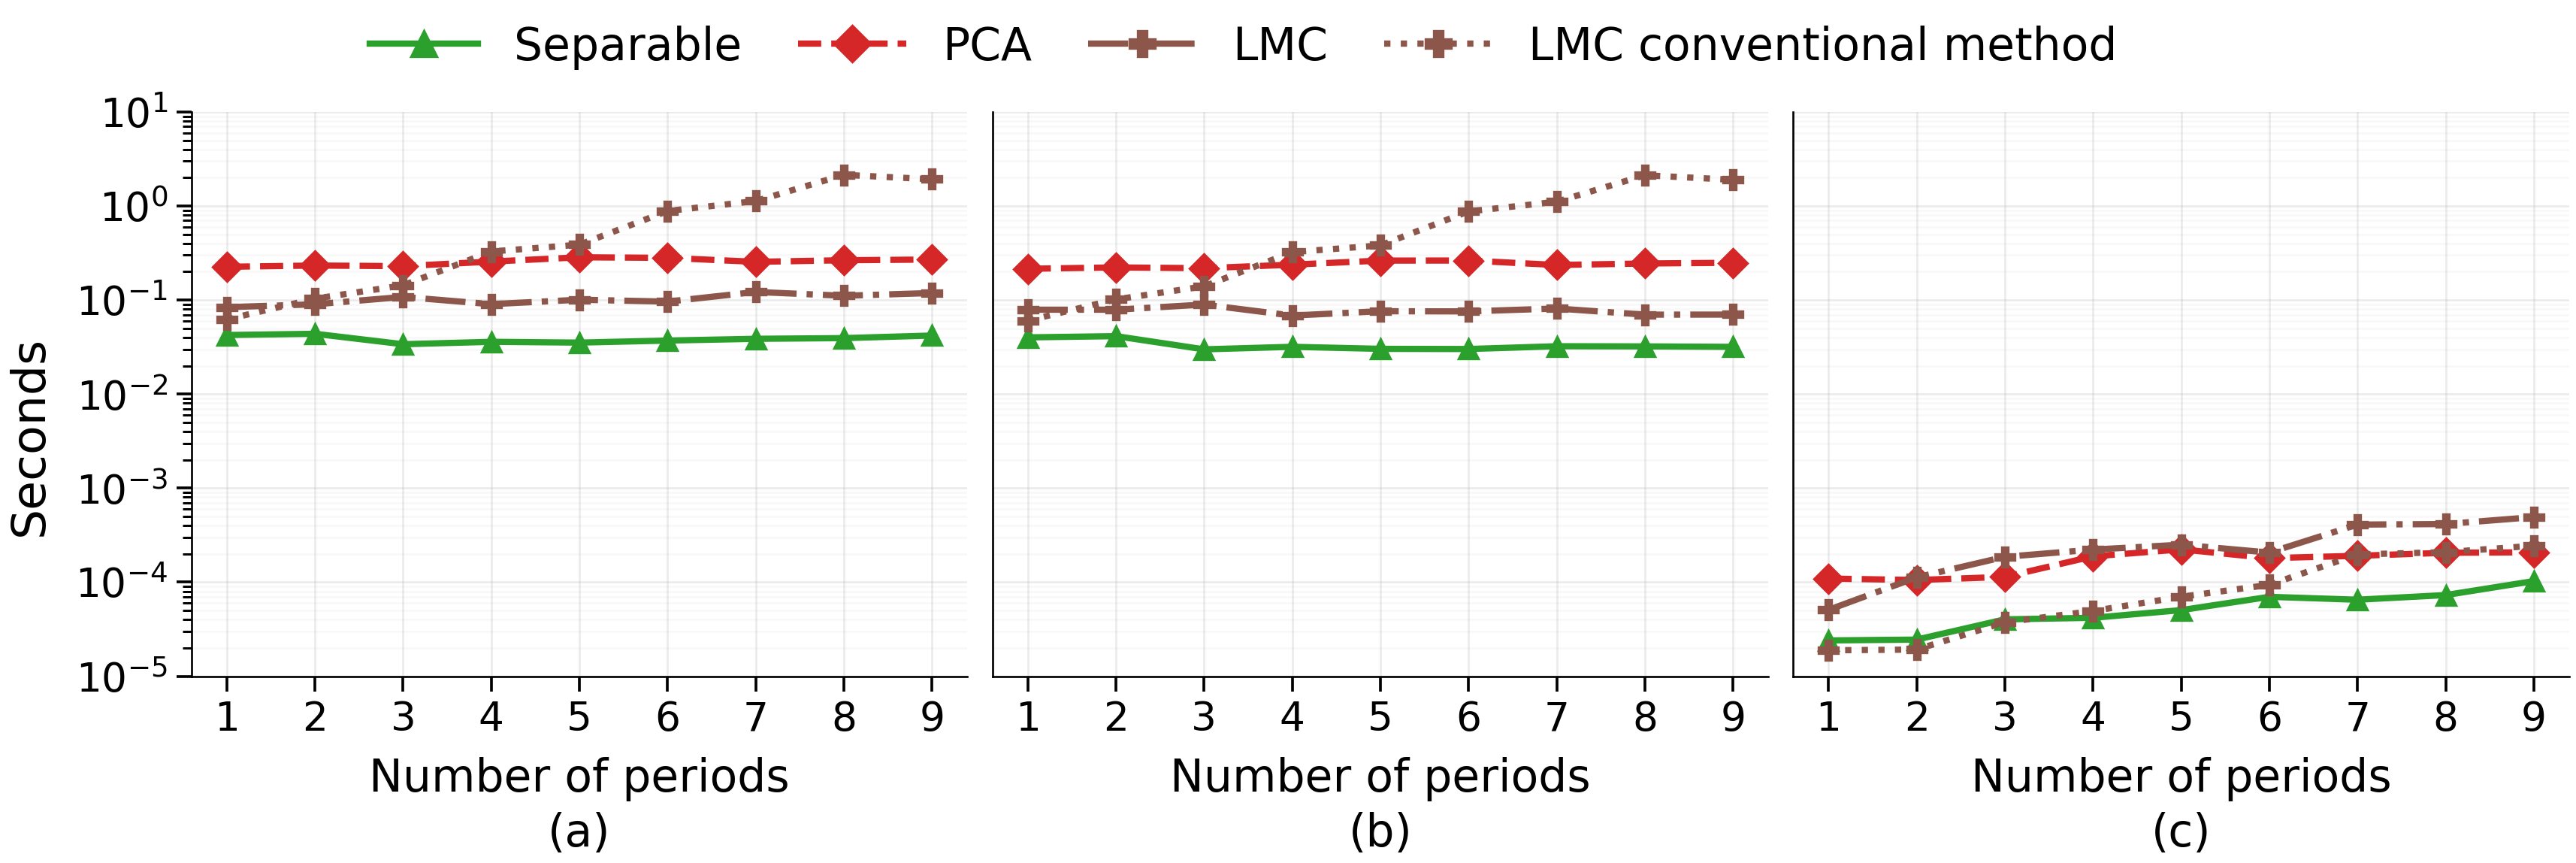

In [7]:
if RERUN:
    main_period = plot_summary(period_run, 'period')
from scripts.common import plotting as p
p.plot_sweep(main_period, x_column='period_count', x_label="Number of periods", output_path=FIGURES / 'fig07_sampling_periods.png', log_x_base=None)
display(Image(filename=str(FIGURES / 'fig07_sampling_periods.png')))

## Recorded main realization sweep

In [8]:
import io
main_realization = pd.read_csv(io.StringIO('method,n_realizations,median_total_seconds,median_setup_seconds,median_first_realization_seconds,median_sampling_seconds_per_realization\r\nIOX full semivariogram,1,3.661567299917806,3.6521539999521337,3.661567299917806,0.0094132999656721\r\nLMC semivariogram,1,0.0855071999831125,0.0847357000457122,0.0855071999831125,0.0007714999374002\r\nMultivariate Matern semivariogram,1,3.6437732999329455,3.636659999960102,3.6437732999329455,0.0071132999728433\r\nPCA semivariogram,1,0.2530604999628849,0.2502662999904714,0.2530604999628849,0.0027941999724134\r\nSBSS semivariogram,1,0.2469970000092871,0.2456440000096336,0.2469970000092871,0.0013529999996535\r\nSeparable kernel semivariogram,1,0.0319334000814706,0.0316973000299185,0.0319334000814706,0.000236100051552\r\nIOX full semivariogram,10,3.863039600022603,3.847941900021397,3.849451670021517,0.0015097700001206\r\nLMC semivariogram,10,0.0924387999111786,0.0879644999513402,0.0884119299473241,0.0004474299959838\r\nMultivariate Matern semivariogram,10,3.777709100046195,3.7579015000374056,3.759882260038285,0.0019807600008789\r\nPCA semivariogram,10,0.2426549000083468,0.2395939999842085,0.2399000899866223,0.0003060900024138\r\nSBSS semivariogram,10,0.228882200026419,0.2265560000087134,0.226788620010484,0.0002326200017705\r\nSeparable kernel semivariogram,10,0.034117600065656,0.0330308000557124,0.0331394800567068,0.0001086800009943\r\nIOX full semivariogram,100,3.82433100003982,3.7820322000188753,3.782455188019085,0.0004229880002094\r\nLMC semivariogram,100,0.1151341000804677,0.0671397000551223,0.0676196440553758,0.0004799440002534\r\nMultivariate Matern semivariogram,100,3.7821976999985054,3.710345700033941,3.711064220033586,0.0007185199996456\r\nPCA semivariogram,100,0.2683819999801926,0.2490502999862656,0.2492436169862048,0.0001933169999392\r\nSBSS semivariogram,100,0.2414381999406032,0.2292594999889843,0.2293812869885005,0.0001217869995161\r\nSeparable kernel semivariogram,100,0.0474916999228298,0.0381833999417722,0.0382764829415828,9.308299981057644e-05\r\nIOX full semivariogram,1000,4.075096400047187,3.493488800013438,3.494070407613472,0.0005816076000337\r\nLMC semivariogram,1000,0.4745843999553472,0.067960700020194,0.0683673237201292,0.0004066236999351\r\nMultivariate Matern semivariogram,1000,4.218482900003437,3.7681032000109553,3.768553579710948,0.0004503796999924\r\nPCA semivariogram,1000,0.44608069997048,0.2357065000105649,0.2359168742105248,0.0002103741999599\r\nSBSS semivariogram,1000,0.3454174000071361,0.2211933000362478,0.2213175241362187,0.0001242240999708\r\nSeparable kernel semivariogram,1000,0.1077164999442175,0.0330190999666228,0.0330937973666004,7.469739997759462e-05\r\nIOX full semivariogram,10000,8.260352200013585,3.635908800002653,3.636371244342654,0.000462444340001\r\nLMC semivariogram,10000,2.997043799958192,0.0757043999619782,0.0759965339019778,0.0002921339399996\r\nMultivariate Matern semivariogram,10000,9.1140502000344,3.8202740999986418,3.820803477608645,0.0005293776100035\r\nPCA semivariogram,10000,2.0659893000265583,0.2498274000245146,0.2500090162145148,0.0001816161900002\r\nSBSS semivariogram,10000,1.35304429999087,0.2361343000084161,0.2362459910084144,0.0001116909999982\r\nSeparable kernel semivariogram,10000,0.7123510000528768,0.0328782000578939,0.0329461473378934,6.794727999949828e-05\r\nLMC conventional method,1,1.9520513000898063,1.946404300164432,1.9520513000898063,0.0056469999253749\r\nLMC conventional method,10,1.8113133998122064,1.8005088998470455,1.8015893498435616,0.0010804499965161\r\nLMC conventional method,100,1.9082633000798523,1.886123599950224,1.8863449969515205,0.0002213970012962\r\nLMC conventional method,1000,2.1142365999985486,1.9460909999907017,1.9462591455907088,0.0001681456000078\r\nLMC conventional method,10000,3.638449099846184,1.88993819989264,1.890113050982636,0.0001748510899953\r\n'))
display(main_realization)

,method,n_realizations,median_total_seconds,median_setup_seconds,median_first_realization_seconds,median_sampling_seconds_per_realization
0,IOX full semivariogram,1,3.661567,3.652154,3.661567,0.009413
1,LMC semivariogram,1,0.085507,0.084736,0.085507,0.000771
2,Multivariate Matern semivariogram,1,3.643773,3.636660,3.643773,0.007113
3,PCA semivariogram,1,0.253060,0.250266,0.253060,0.002794
4,SBSS semivariogram,1,0.246997,0.245644,0.246997,0.001353
5,Separable kernel semivariogram,1,0.031933,0.031697,0.031933,0.000236
6,IOX full semivariogram,10,3.863040,3.847942,3.849452,0.001510
7,LMC semivariogram,10,0.092439,0.087964,0.088412,0.000447
8,Multivariate Matern semivariogram,10,3.777709,3.757902,3.759882,0.001981
9,PCA semivariogram,10,0.242655,0.239594,0.239900,0.000306


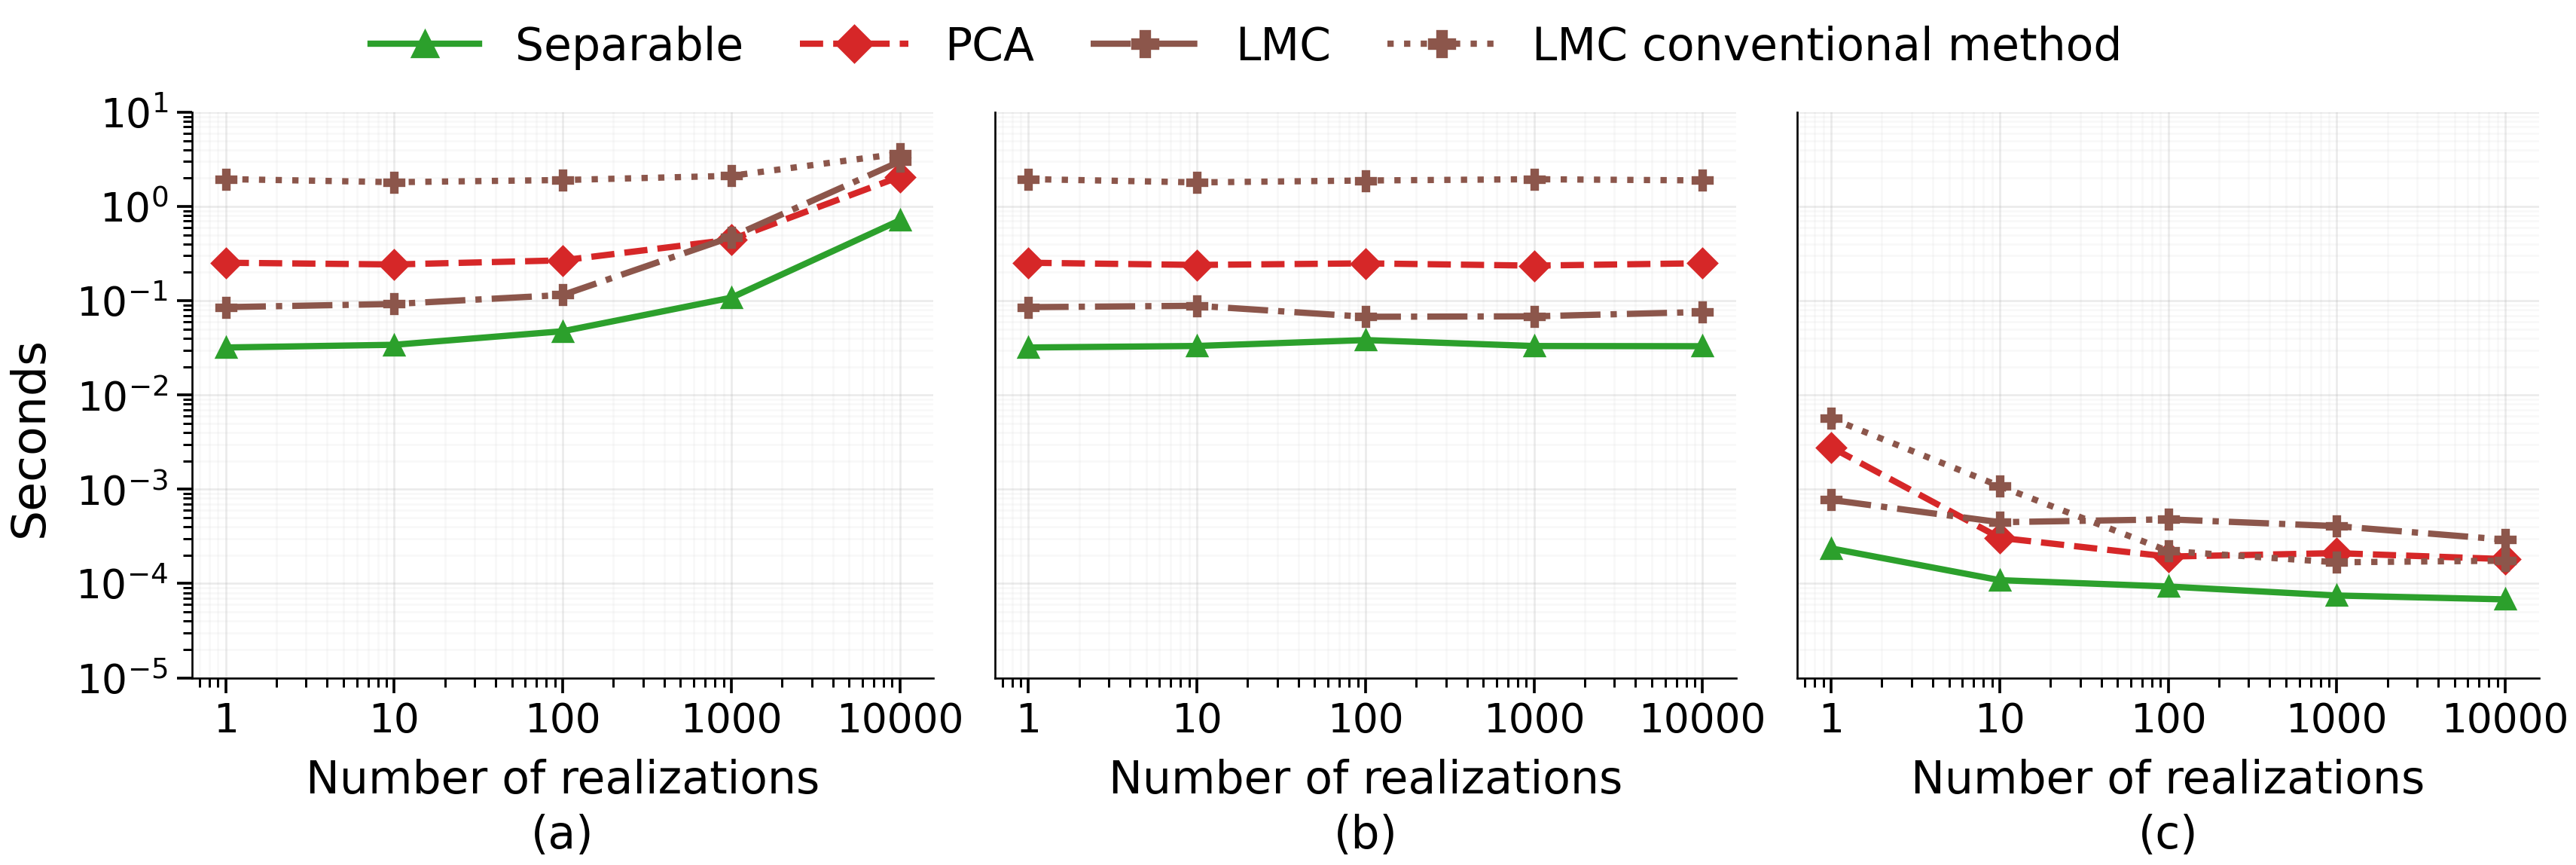

In [9]:
if RERUN:
    main_realization = plot_summary(draw_run, 'realization')
from scripts.common import plotting as p
p.plot_sweep(main_realization, x_column='n_realizations', x_label="Number of realizations", output_path=FIGURES / 'fig08_sampling_realizations.png', log_x_base=10)
display(Image(filename=str(FIGURES / 'fig08_sampling_realizations.png')))

## Recorded supplement station sweep

In [10]:
import io
supplement_station = pd.read_csv(io.StringIO('method,station_count,median_total_seconds,median_setup_seconds,median_first_realization_seconds,median_sampling_seconds_per_realization\r\nIOX full semivariogram,20,0.0031605002004653,0.0019256002269685,0.0019379492267034,1.2348999734967948e-05\r\nLMC semivariogram,20,0.0015173000283539,0.0009164999937638,0.0009225079941097,6.008000345900655e-06\r\nMultivariate Matern semivariogram,20,0.0023121999111026,0.0020620999857783,0.0020646009850315,2.500999253243208e-06\r\nPCA semivariogram,20,0.0015564999775961,0.0012127999798394,0.001216236979817,3.4369999775663018e-06\r\nSBSS semivariogram,20,0.0017642999882809,0.0014658999862149,0.0014688839862355,2.98400002066046e-06\r\nSeparable kernel semivariogram,20,0.0031649000011384,0.0029115999350324,0.0029141329356934,2.533000661060214e-06\r\nIOX full semivariogram,40,0.0055281000677496,0.0047971999738365,0.0048045089747756,7.309000939130783e-06\r\nLMC semivariogram,40,0.002292999997735,0.0010055999737232,0.0010184739739634,1.2874000240117312e-05\r\nMultivariate Matern semivariogram,40,0.0057977996766567,0.0050573998596519,0.0050648038578219,7.4039981700479985e-06\r\nPCA semivariogram,40,0.0021523999748751,0.0015037999837659,0.001510285983677,6.485999911092222e-06\r\nSBSS semivariogram,40,0.0026836000033654,0.0020266000065021,0.0020331700064707,6.569999968633056e-06\r\nSeparable kernel semivariogram,40,0.0021569000091403,0.0014674999983981,0.0014743939985055,6.894000107422471e-06\r\nIOX full semivariogram,80,0.0193684000987559,0.0183433000929653,0.0183535510930232,1.0251000057905912e-05\r\nLMC semivariogram,80,0.0076947000343352,0.0013244000729173,0.0013881030725315,6.370299961417913e-05\r\nMultivariate Matern semivariogram,80,0.0248547000810503,0.0236923999618738,0.0237040229630656,1.162300119176507e-05\r\nPCA semivariogram,80,0.0044342000037431,0.0024447999894618,0.0024646939896047,1.989400014281273e-05\r\nSBSS semivariogram,80,0.0041826000087894,0.0026390000130049,0.0026544360129628,1.5435999957844616e-05\r\nSeparable kernel semivariogram,80,0.0070754000917077,0.0010924000525847,0.0011522300529759,5.983000039122999e-05\r\nIOX full semivariogram,160,0.0791728999465704,0.076835999963805,0.0768593689636327,2.336899982765317e-05\r\nLMC semivariogram,160,0.0183012000052258,0.0035140999825671,0.0036619709827937,0.0001478710002265\r\nMultivariate Matern semivariogram,160,0.0943128999788314,0.0893407999537885,0.0893905209540389,4.972100025042892e-05\r\nPCA semivariogram,160,0.0122052999795414,0.0084225999889895,0.008460426988895,3.782699990551919e-05\r\nSBSS semivariogram,160,0.0125643999199382,0.0085103999590501,0.008550939958659,4.053999960888177e-05\r\nSeparable kernel semivariogram,160,0.0119388999883085,0.0022088999394327,0.0023061999399214,9.730000048875808e-05\r\nIOX full semivariogram,320,0.3300555997993797,0.3245297998655587,0.3245850578648969,5.5257999338209626e-05\r\nLMC semivariogram,320,0.0206252000061795,0.0089172999141737,0.0090343789150938,0.00011707900092\r\nMultivariate Matern semivariogram,320,0.4755600001662969,0.4664718001149595,0.4665626821154728,9.08820005133748e-05\r\nPCA semivariogram,320,0.0437205999623984,0.0359968999982811,0.0360741369979223,7.723699964117259e-05\r\nSBSS semivariogram,320,0.0357513999915681,0.0285282999975606,0.0286005309975007,7.223099994007497e-05\r\nSeparable kernel semivariogram,320,0.010160700068809,0.0058605000376701,0.0059035020379815,4.3002000311389565e-05\r\nIOX full semivariogram,640,1.3872355001512915,1.3645135001279414,1.364740720128175,0.0002272200002335\r\nLMC semivariogram,640,0.1320343998959288,0.0775517999427393,0.0780966259422712,0.0005448259995318\r\nMultivariate Matern semivariogram,640,1.654243800090626,1.6301786999683827,1.6304193509696052,0.0002406510012224\r\nPCA semivariogram,640,0.2456172000383958,0.2249711000476963,0.2251775610476033,0.0002064609999069\r\nSBSS semivariogram,640,0.2409216999658383,0.2279388000024482,0.2280686290020821,0.0001298289996339\r\nSeparable kernel semivariogram,640,0.040504700038582,0.0319282000418752,0.0320139650418423,8.576499996706843e-05\r\nIOX full semivariogram,1280,7.223115500062704,7.157427300000563,7.1580841820011845,0.0006568820006214\r\nLMC semivariogram,1280,0.4686691999668255,0.376663799979724,0.377583853979595,0.000920053999871\r\nMultivariate Matern semivariogram,1280,7.264330900041386,7.200322600081563,7.200962683081161,0.0006400829995982\r\nPCA semivariogram,1280,1.1200362000381574,1.069372000056319,1.0698786420561373,0.0005066419998183\r\nSBSS semivariogram,1280,1.1654944999609145,1.1367393999826163,1.1370269509823994,0.0002875509997829\r\nSeparable kernel semivariogram,1280,0.1758544001495465,0.1569501000922173,0.1571391430927906,0.0001890430005732\r\nIOX full semivariogram,2560,39.27408090024255,39.00774540007114,39.01040875507286,0.002663355001714\r\nLMC semivariogram,2560,1.993351300014183,1.7722820000490174,1.774492693048669,0.0022106929996516\r\nMultivariate Matern semivariogram,2560,40.10302280005999,39.83853460010141,39.841179482101,0.0026448819995857\r\nPCA semivariogram,2560,5.681117699947208,5.551262299995869,5.552560853995383,0.0012985539995133\r\nSBSS semivariogram,2560,5.127509999962058,5.059469599975273,5.060150003975141,0.0006804039998678\r\nSeparable kernel semivariogram,2560,0.7797128999372944,0.7244124999269843,0.7249655039270874,0.0005530040001031\r\nIOX full semivariogram,5120,,,,\r\nLMC semivariogram,5120,8.347289900062606,7.83928630000446,7.8443663360050415,0.0050800360005814\r\nMultivariate Matern semivariogram,5120,,,,\r\nPCA semivariogram,5120,28.199070999922697,27.667511299951,27.67282689695072,0.0053155969997169\r\nSBSS semivariogram,5120,20.32797850004863,20.152029999997467,20.15378948499798,0.0017594850005116\r\nSeparable kernel semivariogram,5120,3.292329799965956,3.1668738999869674,3.1681284589867573,0.0012545589997898\r\n'))
display(supplement_station)

,method,station_count,median_total_seconds,median_setup_seconds,median_first_realization_seconds,median_sampling_seconds_per_realization
0,IOX full semivariogram,20,0.003161,0.001926,0.001938,0.000012
1,LMC semivariogram,20,0.001517,0.000916,0.000923,0.000006
2,Multivariate Matern semivariogram,20,0.002312,0.002062,0.002065,0.000003
3,PCA semivariogram,20,0.001556,0.001213,0.001216,0.000003
4,SBSS semivariogram,20,0.001764,0.001466,0.001469,0.000003
5,Separable kernel semivariogram,20,0.003165,0.002912,0.002914,0.000003
6,IOX full semivariogram,40,0.005528,0.004797,0.004805,0.000007
7,LMC semivariogram,40,0.002293,0.001006,0.001018,0.000013
8,Multivariate Matern semivariogram,40,0.005798,0.005057,0.005065,0.000007
9,PCA semivariogram,40,0.002152,0.001504,0.001510,0.000006


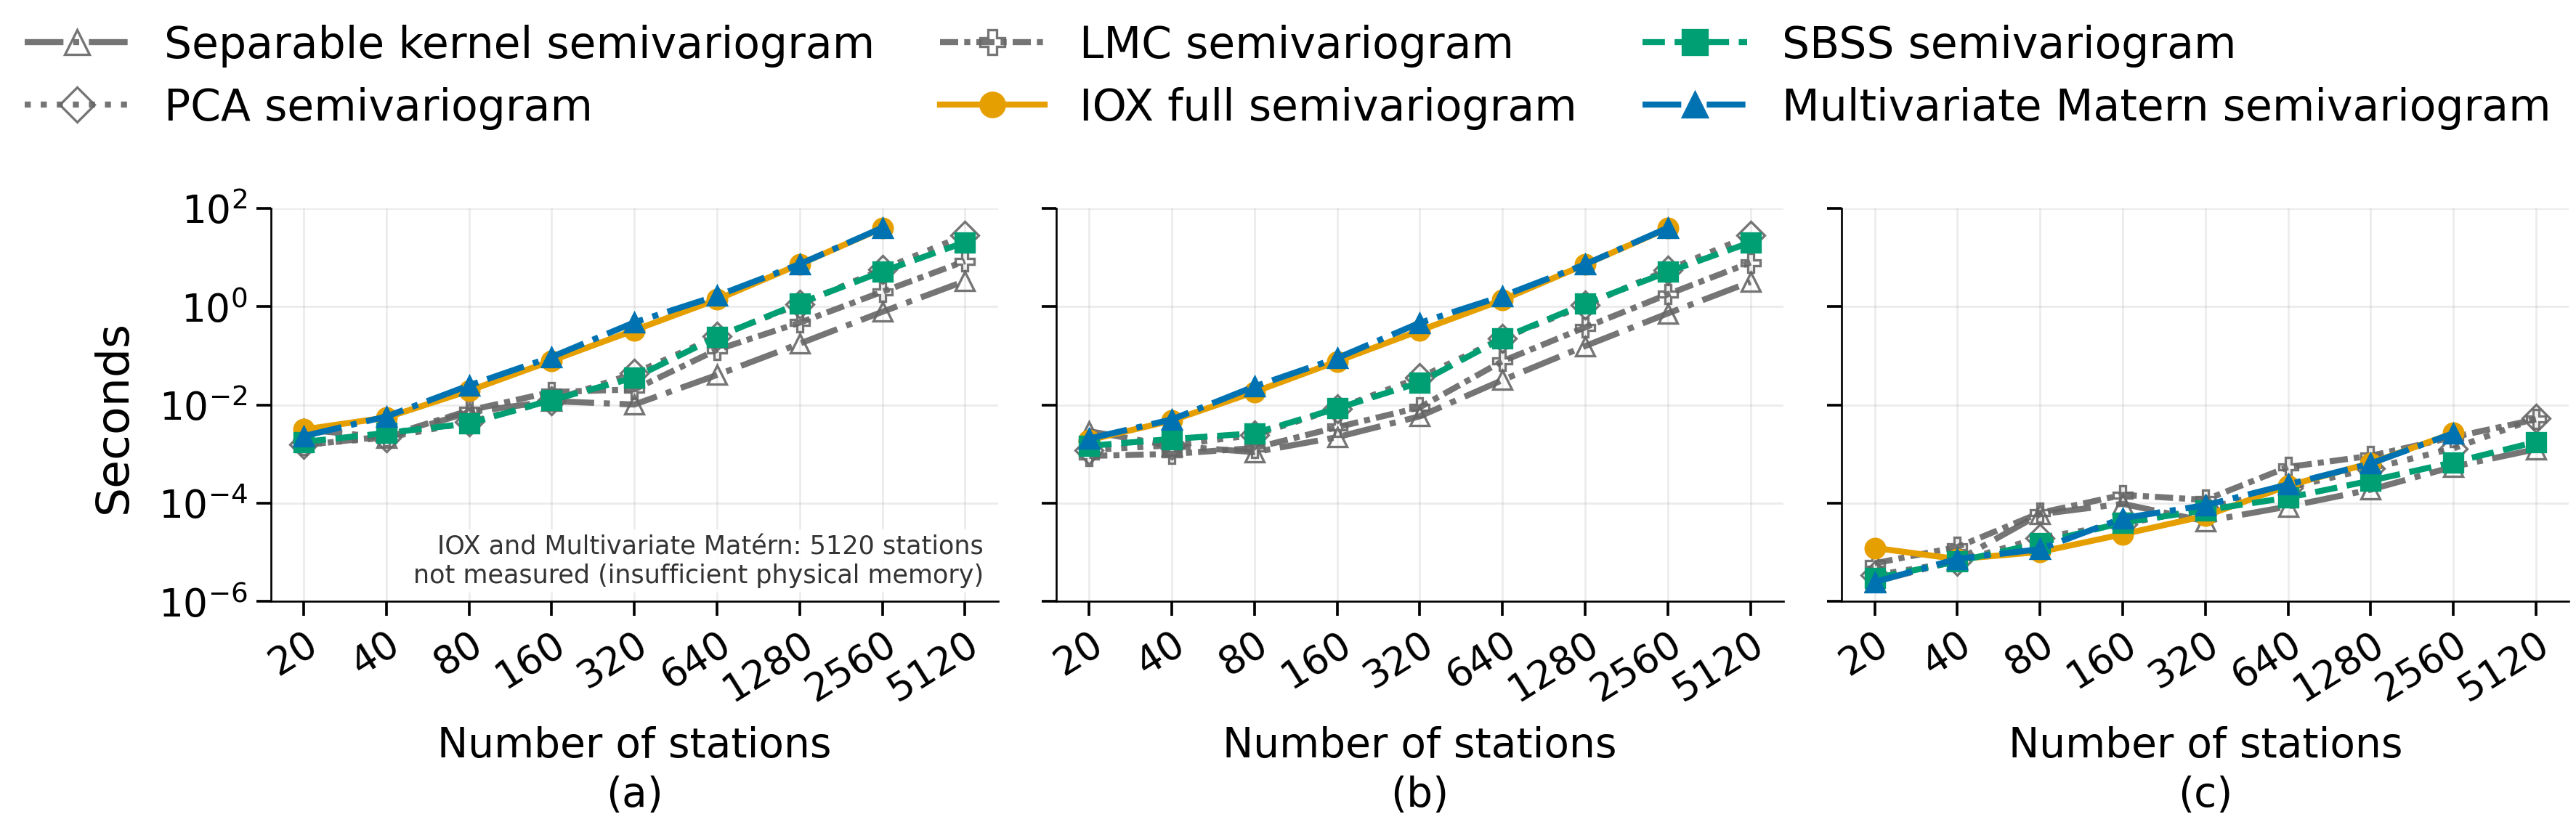

In [11]:
if RERUN_SUPPLEMENT:
    supplement_station = plot_summary(supplement_station_run, 'station')
from scripts.common import plotting as p
p.FIGURE_DIR = FIGURES
p._plot_sampling_sweep(supplement_station, 'station_count', "Number of stations", 'station' != "period", 'figS04_sampling_stations.png')
display(Image(filename=str(FIGURES / 'figS04_sampling_stations.png')))

## Recorded supplement period sweep

In [12]:
import io
supplement_period = pd.read_csv(io.StringIO('method,period_count,median_total_seconds,median_setup_seconds,median_first_realization_seconds,median_sampling_seconds_per_realization\r\nIOX full semivariogram,1,0.0393802999751642,0.038344100001268,0.038354462001007,1.0361999738961458e-05\r\nLMC semivariogram,1,0.0840094999875873,0.0789281000616028,0.0789789140608627,5.081399925984442e-05\r\nMultivariate Matern semivariogram,1,0.039088100020308,0.0375454999739304,0.0375609259743941,1.542600046377629e-05\r\nPCA semivariogram,1,0.225872499984689,0.214936000003945,0.2150453650037525,0.0001093649998074\r\nSBSS semivariogram,1,0.268491199996788,0.2593143000267446,0.259406069026445,9.17689997004345e-05\r\nSeparable kernel semivariogram,1,0.0424730000086128,0.0400674000848084,0.0400914560840465,2.4055999238044023e-05\r\nIOX full semivariogram,2,0.1279961999971419,0.1253782999701798,0.1254044789704494,2.617900026962161e-05\r\nLMC semivariogram,2,0.0901066999649629,0.0788394999690353,0.0789521719689946,0.0001126719999592\r\nMultivariate Matern semivariogram,2,0.1301220000023022,0.1276192999794148,0.1276443269796436,2.5027000228874387e-05\r\nPCA semivariogram,2,0.232779300014954,0.2222282000002451,0.2223337110003922,0.000105511000147\r\nSBSS semivariogram,2,0.2329373999964445,0.2224761000252328,0.222580713024945,0.0001046129997121\r\nSeparable kernel semivariogram,2,0.0437771999277174,0.0413228999823331,0.041347442981787,2.454299945384264e-05\r\nIOX full semivariogram,3,0.3163701999583281,0.3110883999615907,0.3111412179615581,5.281799996737391e-05\r\nLMC semivariogram,3,0.1080439001088962,0.0894260000204667,0.089612179021351,0.0001861790008842\r\nMultivariate Matern semivariogram,3,0.2831679999944754,0.2781054999795742,0.2781561249797232,5.062500014901161e-05\r\nPCA semivariogram,3,0.2293828999972902,0.2179872000124305,0.2181011570122791,0.0001139569998485\r\nSBSS semivariogram,3,0.2357708000345155,0.2252226000418886,0.2253280820418149,0.0001054819999262\r\nSeparable kernel semivariogram,3,0.0339071999769657,0.0298795000417158,0.0299197770410683,4.027699935249984e-05\r\nIOX full semivariogram,4,0.6615011999383569,0.6497661999892443,0.6498835499887354,0.0001173499994911\r\nLMC semivariogram,4,0.0904085000511258,0.0681922000367194,0.0684143630368635,0.000222163000144\r\nMultivariate Matern semivariogram,4,0.7089381000259891,0.69435170001816,0.6944975640182384,0.0001458640000782\r\nPCA semivariogram,4,0.2565590000012889,0.2377219999907538,0.2379103699908591,0.0001883700001053\r\nSBSS semivariogram,4,0.2539176999707706,0.2434866999974474,0.2435910099971806,0.0001043099997332\r\nSeparable kernel semivariogram,4,0.0359750000061467,0.0317900000372901,0.0318318500369787,4.184999968856573e-05\r\nIOX full semivariogram,5,1.1078264999669043,1.0888105999911204,1.0890007589908783,0.0001901589997578\r\nLMC semivariogram,5,0.1008816998219117,0.0758198999101296,0.0760705179092474,0.0002506179991178\r\nMultivariate Matern semivariogram,5,1.075701600057073,1.0559922000393271,1.0561892940395046,0.0001970940001774\r\nPCA semivariogram,5,0.2849552999832667,0.2626008999650366,0.262824443965219,0.0002235440001823\r\nSBSS semivariogram,5,0.2480465000262484,0.236917300033383,0.2370285920333117,0.0001112919999286\r\nSeparable kernel semivariogram,5,0.0352849999908357,0.0302370999706909,0.0302875789708923,5.04790002014488e-05\r\nIOX full semivariogram,6,1.5519547000294551,1.533306099998299,1.5334925859986106,0.0001864860003115\r\nLMC semivariogram,6,0.0962150000268593,0.0755493000615388,0.075755957061192,0.0002066569996532\r\nMultivariate Matern semivariogram,6,1.6471698000095785,1.6088112000143155,1.609194786014268,0.0003835859999526\r\nPCA semivariogram,6,0.2810405999189242,0.2630117999506183,0.2631920879503013,0.000180287999683\r\nSBSS semivariogram,6,0.2449177000089548,0.2343615000136196,0.234467062013573,0.0001055619999533\r\nSeparable kernel semivariogram,6,0.0370865000877529,0.0300923000322654,0.0301622420328203,6.994200055487454e-05\r\nIOX full semivariogram,7,2.234480899991468,2.1838851000065915,2.1843910580064403,0.0005059579998487\r\nLMC semivariogram,7,0.1219099999871105,0.0809184999670833,0.0813284149672836,0.0004099150002002\r\nMultivariate Matern semivariogram,7,2.1581337999668904,2.10678159998497,2.107295121984789,0.0005135219998192\r\nPCA semivariogram,7,0.2548775000614114,0.235786100034602,0.2359770140348701,0.000190914000268\r\nSBSS semivariogram,7,0.2527185000362806,0.2413563000154681,0.2414699220156762,0.0001136220002081\r\nSeparable kernel semivariogram,7,0.0387296000262722,0.0322145000100135,0.0322796510101761,6.515100016258656e-05\r\nIOX full semivariogram,8,3.010857200017199,2.980170199996792,2.980477069996996,0.000306870000204\r\nLMC semivariogram,8,0.1110921999206766,0.0695443999720737,0.0699598779715597,0.000415477999486\r\nMultivariate Matern semivariogram,8,3.1907795000006445,3.1314454000093974,3.13203874100931,0.0005933409999124\r\nPCA semivariogram,8,0.2651837999583222,0.2446193999494426,0.2448250439495314,0.0002056440000887\r\nSBSS semivariogram,8,0.2419394999742508,0.2307965999934822,0.2309080289932899,0.0001114289998076\r\nSeparable kernel semivariogram,8,0.0393776000710204,0.0320773000130429,0.0321503030136227,7.300300057977438e-05\r\nIOX full semivariogram,9,3.7453175999689847,3.695501699985471,3.6959998589853056,0.0004981589998351\r\nLMC semivariogram,9,0.1188082001172006,0.0695742000825703,0.0700665400829166,0.0004923400003463\r\nMultivariate Matern semivariogram,9,3.7515717000351287,3.682488800026477,3.683179629026563,0.0006908290000865\r\nPCA semivariogram,9,0.2697225000010803,0.248918599972967,0.2491266389732482,0.0002080390002811\r\nSBSS semivariogram,9,0.2582202999619767,0.2460286999703385,0.2461506159702548,0.0001219159999163\r\nSeparable kernel semivariogram,9,0.0419626000802964,0.0316839000442996,0.0317866870446596,0.0001027870003599\r\n'))
display(supplement_period)

,method,period_count,median_total_seconds,median_setup_seconds,median_first_realization_seconds,median_sampling_seconds_per_realization
0,IOX full semivariogram,1,0.039380,0.038344,0.038354,0.000010
1,LMC semivariogram,1,0.084009,0.078928,0.078979,0.000051
2,Multivariate Matern semivariogram,1,0.039088,0.037545,0.037561,0.000015
3,PCA semivariogram,1,0.225872,0.214936,0.215045,0.000109
4,SBSS semivariogram,1,0.268491,0.259314,0.259406,0.000092
5,Separable kernel semivariogram,1,0.042473,0.040067,0.040091,0.000024
6,IOX full semivariogram,2,0.127996,0.125378,0.125404,0.000026
7,LMC semivariogram,2,0.090107,0.078839,0.078952,0.000113
8,Multivariate Matern semivariogram,2,0.130122,0.127619,0.127644,0.000025
9,PCA semivariogram,2,0.232779,0.222228,0.222334,0.000106


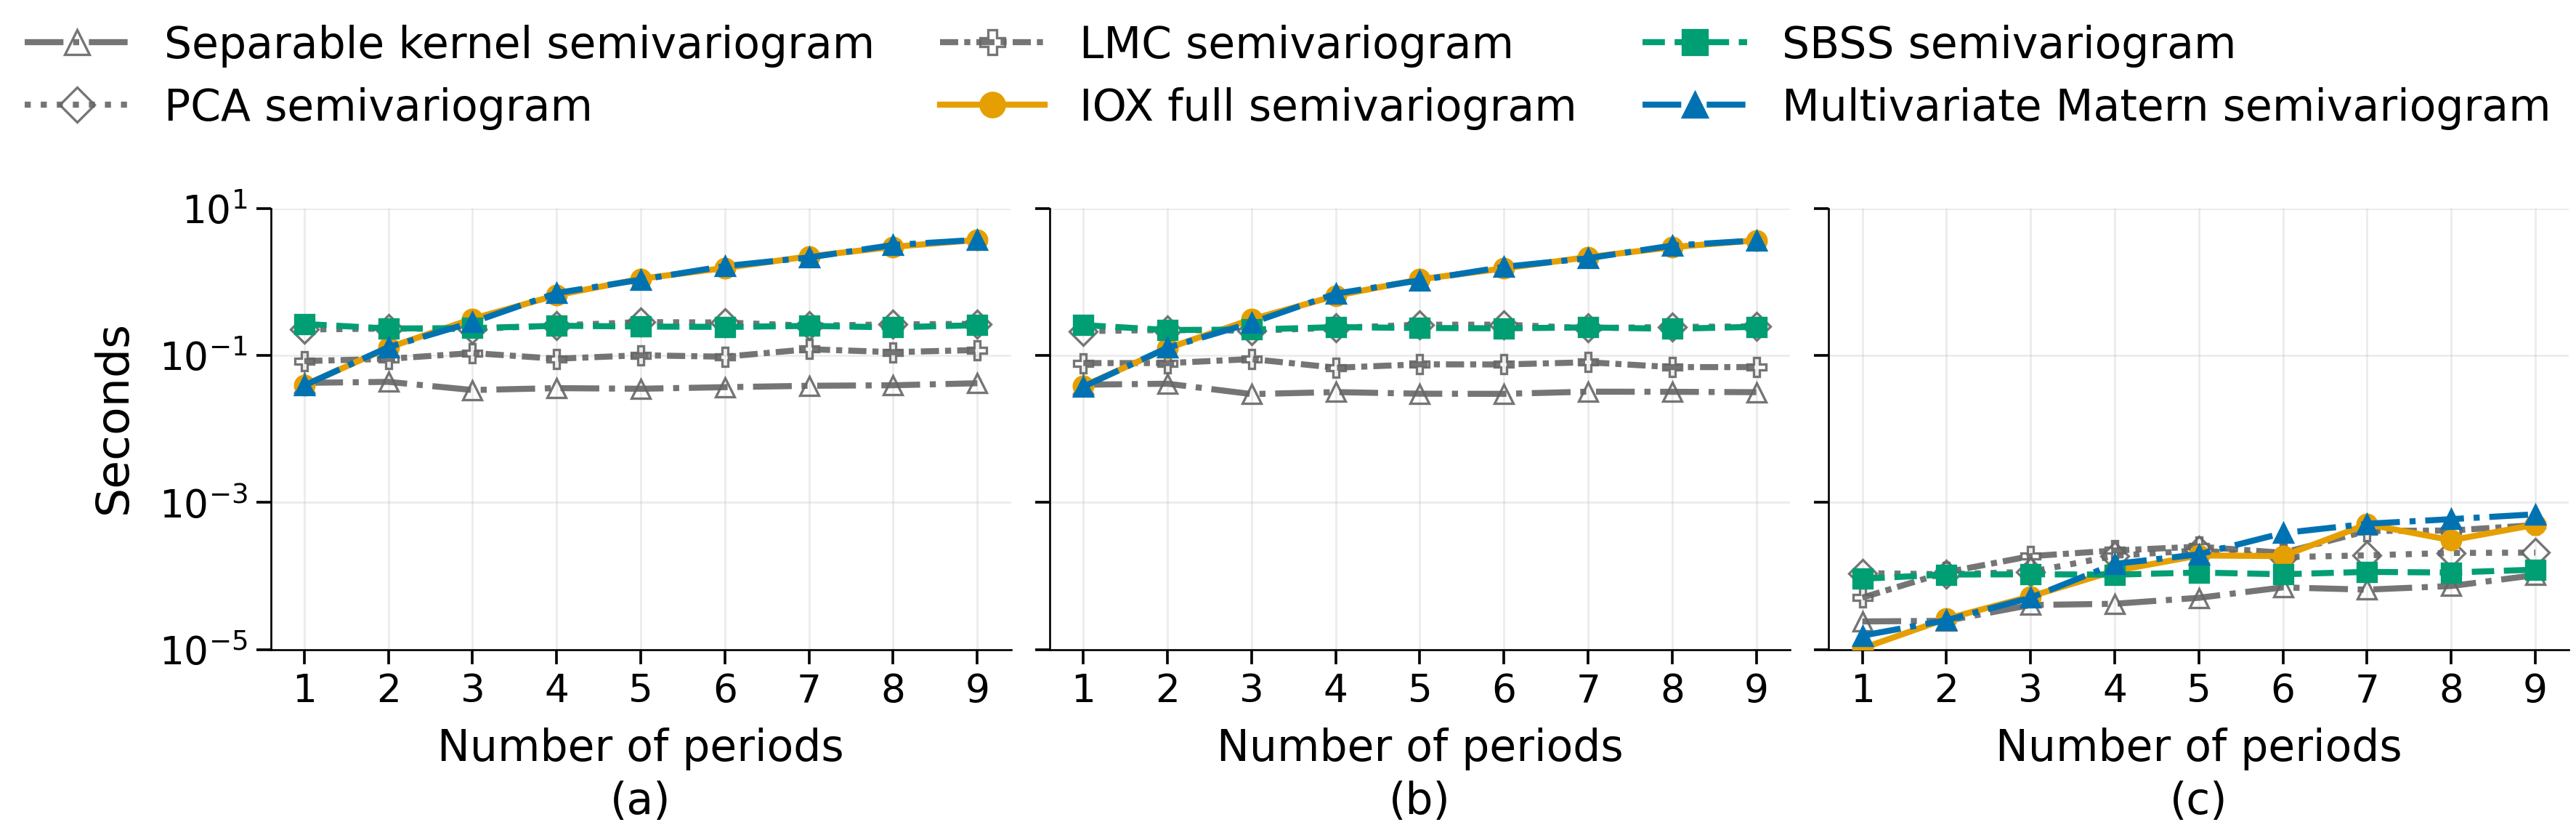

In [13]:
if RERUN_SUPPLEMENT:
    supplement_period = plot_summary(supplement_period_run, 'period')
from scripts.common import plotting as p
p.FIGURE_DIR = FIGURES
p._plot_sampling_sweep(supplement_period, 'period_count', "Number of periods", 'period' != "period", 'figS05_sampling_periods.png')
display(Image(filename=str(FIGURES / 'figS05_sampling_periods.png')))

## Recorded supplement realization sweep

In [14]:
import io
supplement_realization = pd.read_csv(io.StringIO('method,n_realizations,median_total_seconds,median_setup_seconds,median_first_realization_seconds,median_sampling_seconds_per_realization\r\nIOX full semivariogram,1,3.661567299917806,3.6521539999521337,3.661567299917806,0.0094132999656721\r\nLMC semivariogram,1,0.0855071999831125,0.0847357000457122,0.0855071999831125,0.0007714999374002\r\nMultivariate Matern semivariogram,1,3.6437732999329455,3.636659999960102,3.6437732999329455,0.0071132999728433\r\nPCA semivariogram,1,0.2530604999628849,0.2502662999904714,0.2530604999628849,0.0027941999724134\r\nSBSS semivariogram,1,0.2469970000092871,0.2456440000096336,0.2469970000092871,0.0013529999996535\r\nSeparable kernel semivariogram,1,0.0319334000814706,0.0316973000299185,0.0319334000814706,0.000236100051552\r\nIOX full semivariogram,10,3.863039600022603,3.847941900021397,3.849451670021517,0.0015097700001206\r\nLMC semivariogram,10,0.0924387999111786,0.0879644999513402,0.0884119299473241,0.0004474299959838\r\nMultivariate Matern semivariogram,10,3.777709100046195,3.7579015000374056,3.759882260038285,0.0019807600008789\r\nPCA semivariogram,10,0.2426549000083468,0.2395939999842085,0.2399000899866223,0.0003060900024138\r\nSBSS semivariogram,10,0.228882200026419,0.2265560000087134,0.226788620010484,0.0002326200017705\r\nSeparable kernel semivariogram,10,0.034117600065656,0.0330308000557124,0.0331394800567068,0.0001086800009943\r\nIOX full semivariogram,100,3.82433100003982,3.7820322000188753,3.782455188019085,0.0004229880002094\r\nLMC semivariogram,100,0.1151341000804677,0.0671397000551223,0.0676196440553758,0.0004799440002534\r\nMultivariate Matern semivariogram,100,3.7821976999985054,3.710345700033941,3.711064220033586,0.0007185199996456\r\nPCA semivariogram,100,0.2683819999801926,0.2490502999862656,0.2492436169862048,0.0001933169999392\r\nSBSS semivariogram,100,0.2414381999406032,0.2292594999889843,0.2293812869885005,0.0001217869995161\r\nSeparable kernel semivariogram,100,0.0474916999228298,0.0381833999417722,0.0382764829415828,9.308299981057644e-05\r\nIOX full semivariogram,1000,4.075096400047187,3.493488800013438,3.494070407613472,0.0005816076000337\r\nLMC semivariogram,1000,0.4745843999553472,0.067960700020194,0.0683673237201292,0.0004066236999351\r\nMultivariate Matern semivariogram,1000,4.218482900003437,3.7681032000109553,3.768553579710948,0.0004503796999924\r\nPCA semivariogram,1000,0.44608069997048,0.2357065000105649,0.2359168742105248,0.0002103741999599\r\nSBSS semivariogram,1000,0.3454174000071361,0.2211933000362478,0.2213175241362187,0.0001242240999708\r\nSeparable kernel semivariogram,1000,0.1077164999442175,0.0330190999666228,0.0330937973666004,7.469739997759462e-05\r\nIOX full semivariogram,10000,8.260352200013585,3.635908800002653,3.636371244342654,0.000462444340001\r\nLMC semivariogram,10000,2.997043799958192,0.0757043999619782,0.0759965339019778,0.0002921339399996\r\nMultivariate Matern semivariogram,10000,9.1140502000344,3.8202740999986418,3.820803477608645,0.0005293776100035\r\nPCA semivariogram,10000,2.0659893000265583,0.2498274000245146,0.2500090162145148,0.0001816161900002\r\nSBSS semivariogram,10000,1.35304429999087,0.2361343000084161,0.2362459910084144,0.0001116909999982\r\nSeparable kernel semivariogram,10000,0.7123510000528768,0.0328782000578939,0.0329461473378934,6.794727999949828e-05\r\n'))
display(supplement_realization)

,method,n_realizations,median_total_seconds,median_setup_seconds,median_first_realization_seconds,median_sampling_seconds_per_realization
0,IOX full semivariogram,1,3.661567,3.652154,3.661567,0.009413
1,LMC semivariogram,1,0.085507,0.084736,0.085507,0.000771
2,Multivariate Matern semivariogram,1,3.643773,3.636660,3.643773,0.007113
3,PCA semivariogram,1,0.253060,0.250266,0.253060,0.002794
4,SBSS semivariogram,1,0.246997,0.245644,0.246997,0.001353
5,Separable kernel semivariogram,1,0.031933,0.031697,0.031933,0.000236
6,IOX full semivariogram,10,3.863040,3.847942,3.849452,0.001510
7,LMC semivariogram,10,0.092439,0.087964,0.088412,0.000447
8,Multivariate Matern semivariogram,10,3.777709,3.757902,3.759882,0.001981
9,PCA semivariogram,10,0.242655,0.239594,0.239900,0.000306


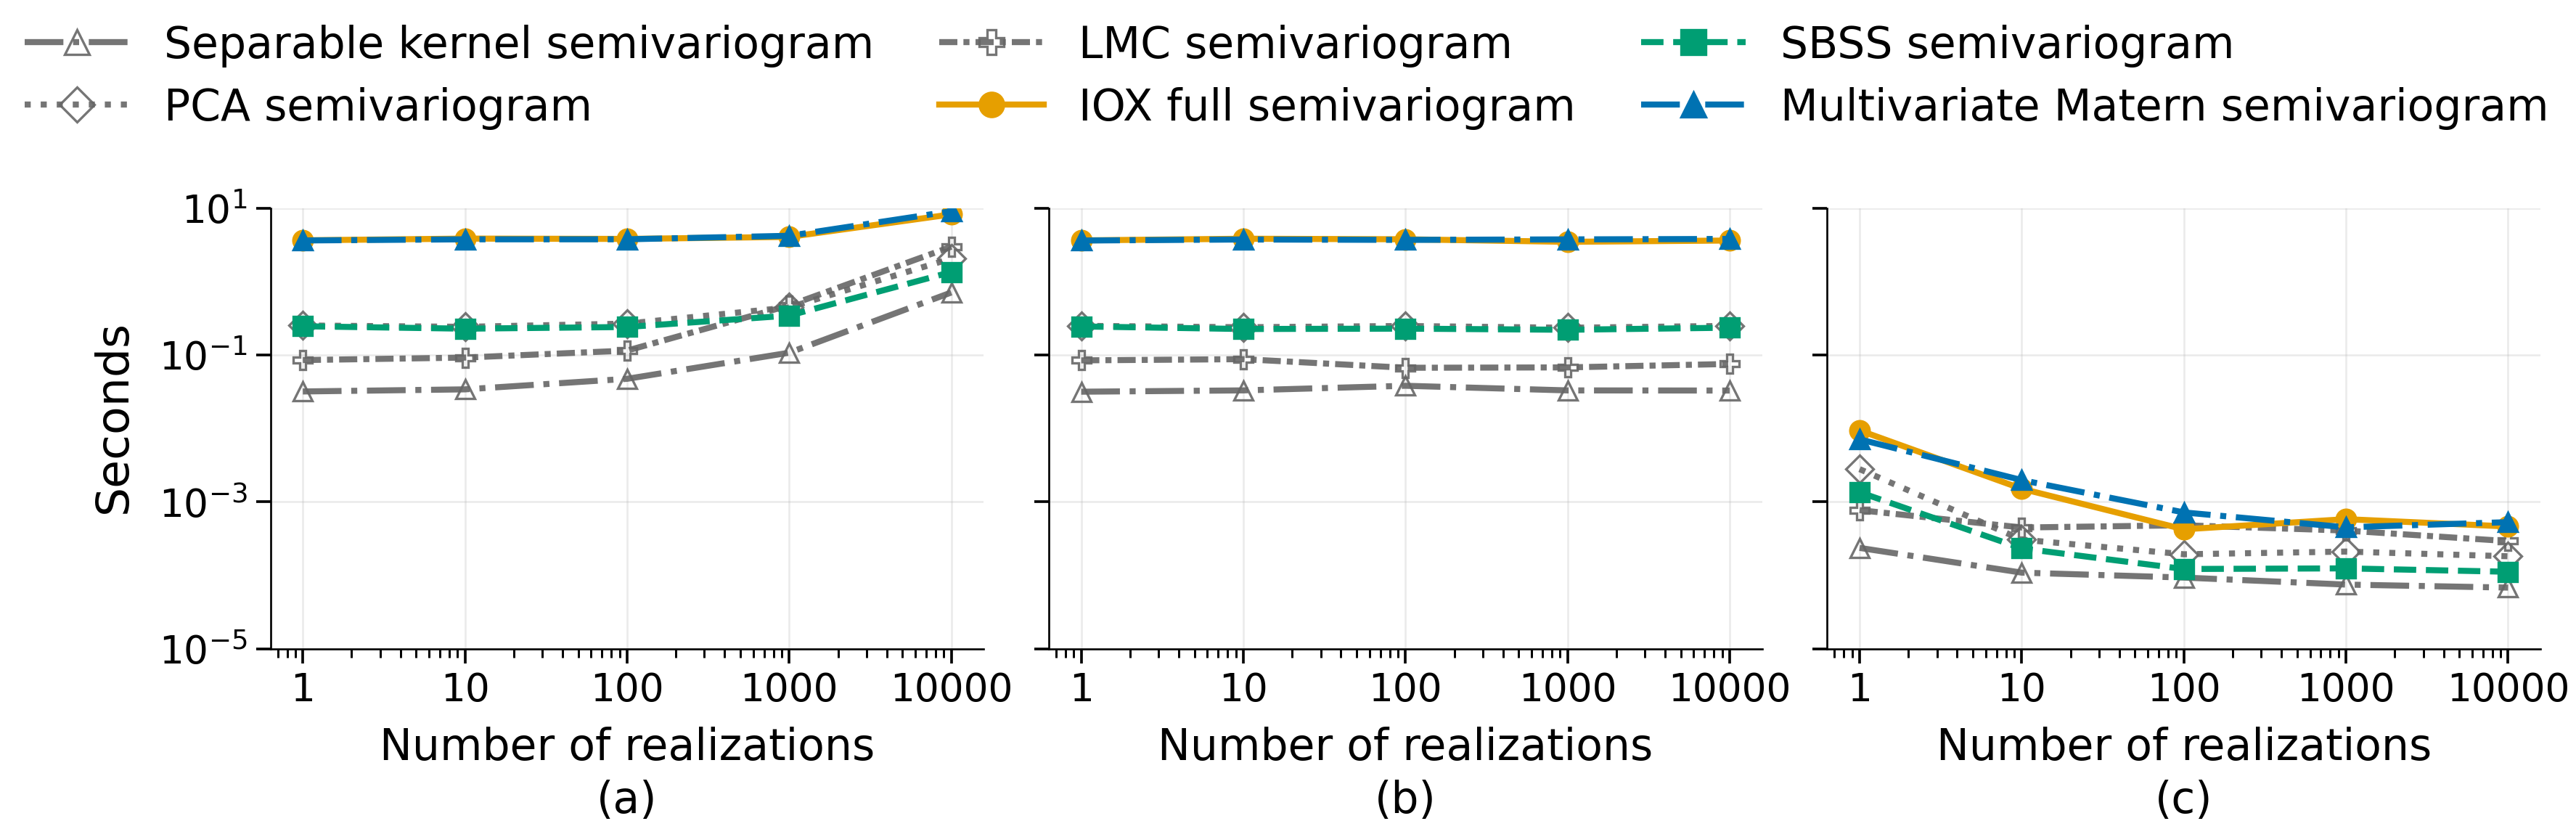

In [15]:
if RERUN_SUPPLEMENT:
    supplement_realization = plot_summary(supplement_realization_run, 'realization')
from scripts.common import plotting as p
p.FIGURE_DIR = FIGURES
p._plot_sampling_sweep(supplement_realization, 'n_realizations', "Number of realizations", 'realization' != "period", 'figS06_sampling_realizations.png')
display(Image(filename=str(FIGURES / 'figS06_sampling_realizations.png')))